In [1]:
# Поместите в переменную names_list список со строками имён
# Отберите из них только те, где wealth принимает значение 'medium, а возраст составляет больше 35.
# Добавьте в исследуемый нами датафрэйм df колонку older_than_30, в которой будет информация превышает ли значение переменной возраста 30 лет или нет (булево значение)
# Получите число уникальных значений для каждой колонки и присвойте её переменной unique_num.
#  Проведите inner join датафрейма data с df из предыдущего шага, объединив их по колонке client_id
# Вернемся к данным по поездкам на такси. На этот раз – из Перу, с рейтингами водителей, пассажиров, координатами, и парой других деталей. Загрузите датасет, используя ; в качестве разделителя. Также укажите, что столбцы start_at, end_at, arrived_at нужно прочитать как даты.
# Проверьте, с какой платформы было сделано больше всего заказов.  В ответе укажите значение в %, округлённое до целого.
# Агрегируйте данные и постройте барчарт, где по оси x будет расположено название платформы (source), а по оси y – количество заказов (абсолютные значения).
# Используйте sns.countplot и проверьте, какой тип поездки (icon) встречался чаще всего.
# С помощью sns.countplot и параметра hue визуализируйте распределение переменной end_state
# Проверим, как распределены оценки водителей (driver_score).


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
names = 'Name1 Surname1, Name2 Surname2, Name3 Surname3, Name4 Surname4'

name_list = names.split(',')
name_list

['Name1 Surname1', ' Name2 Surname2', ' Name3 Surname3', ' Name4 Surname4']

In [4]:
df_1 = pd.DataFrame({
    'client_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'sex': ['F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M'],
    'wealth': ['high', 'medium', 'low', 'medium', 'high',
               'low', 'medium', 'high', 'low', 'medium'],
    'age': [25, 41, 19, 37, 56, 28, 45, 33, 22, 39]
})

df_1.dtypes

client_id    int64
sex            str
wealth         str
age          int64
dtype: object

In [5]:
df_query = df_1.query('wealth == "medium" and age > 35')
df_query

,client_id,sex,wealth,age
1,2,M,medium,41
3,4,M,medium,37
6,7,F,medium,45
9,10,M,medium,39


In [6]:
df_1['older_than_30'] = df_1.age > 30
df_1
# lambda x: x >30 ???

,client_id,sex,wealth,age,older_than_30
0,1,F,high,25,False
1,2,M,medium,41,True
2,3,F,low,19,False
3,4,M,medium,37,True
4,5,F,high,56,True
5,6,M,low,28,False
6,7,F,medium,45,True
7,8,M,high,33,True
8,9,F,low,22,False
9,10,M,medium,39,True


In [8]:
unique_num = df_1.nunique

unique_num

<bound method DataFrame.nunique of    client_id sex  wealth  age  older_than_30
0          1   F    high   25          False
1          2   M  medium   41           True
2          3   F     low   19          False
3          4   M  medium   37           True
4          5   F    high   56           True
5          6   M     low   28          False
6          7   F  medium   45           True
7          8   M    high   33           True
8          9   F     low   22          False
9         10   M  medium   39           True>

In [9]:
data = pd.DataFrame({
    'client_id': [1, 2, 3, 5, 6, 8, 10, 11],
    'salary': [75000, 52000, 31000, 99000, 47000, 88000, 65000, 43000],
    'city': ['Москва', 'Казань', 'Самара', 'Сочи',
             'Пермь', 'Москва', 'Тула', 'Уфа']
})

data

,client_id,salary,city
0,1,75000,Москва
1,2,52000,Казань
2,3,31000,Самара
3,5,99000,Сочи
4,6,47000,Пермь
5,8,88000,Москва
6,10,65000,Тула
7,11,43000,Уфа


In [22]:
df_1_with_data = df_1.merge(data, on = 'client_id', how = 'inner')

df_1_with_data

,client_id,sex,wealth,age,older_than_30,salary,city
0,1,F,high,25,False,75000,Москва
1,2,M,medium,41,True,52000,Казань
2,3,F,low,19,False,31000,Самара
3,5,F,high,56,True,99000,Сочи
4,6,M,low,28,False,47000,Пермь
5,8,M,high,33,True,88000,Москва
6,10,M,medium,39,True,65000,Тула


In [11]:
companies = pd.DataFrame({
    'company': ['Google', 'Google', 'Google',
                'Apple', 'Apple',
                'Yandex', 'Yandex', 'Yandex',
                'VK', 'VK',
                'Ozon', 'Ozon'],
    'income': [120, 180, 150,
               200, 230,
               90, 100, 110,
               70, 80,
               130, 140]
})

companies.to_csv('hw_3_dataframe_companies.csv', sep = ';', index=False)

In [21]:
#функция, которая возвращает агрегированный датафрейм
def read_n_agg(path):
    return pd.read_csv(path, sep=';') \
    .groupby('company') \
    .agg({'income': 'mean'})

read_n_agg('hw_3_dataframe_companies.csv')

,income
company,
Apple,215.0
Google,150.0
Ozon,135.0
VK,75.0
Yandex,100.0


In [13]:
taxi = pd.read_csv('C:/Work/Analytics/taxi_peru.csv', sep=';', encoding= 'windows-1251', parse_dates= ['start_at','end_at','arrived_at'])
taxi.columns

Index(['journey_id', 'user_id', 'driver_id', 'taxi_id', 'icon', 'start_type',
       'start_at', 'start_lat', 'start_lon', 'end_at', 'end_lat', 'end_lon',
       'end_state', 'driver_start_lon', 'arrived_at', 'source', 'driver_score',
       'rider_score'],
      dtype='str')

In [20]:
taxi.head(10)

,journey_id,user_id,driver_id,taxi_id,icon,start_type,start_at,start_lat,start_lon,end_at,end_lat,end_lon,end_state,driver_start_lon,arrived_at,source,driver_score,rider_score
0,1,1048,234,45,car,reserved,2021-05-03 09:11:00,-11.842417,-77.043378,2021-05-03 09:24:00,-11.808567,-77.005895,drop off,-77.049889,2021-05-03 09:16:00,Android,4,0
1,2,1005,205,52,car,reserved,2021-05-20 20:31:00,-11.998962,-77.147362,2021-05-20 21:14:00,-11.975758,-77.187158,drop off,-77.130916,2021-05-20 20:33:00,iPhone,5,5
2,3,1040,200,35,motorbike,asap,2021-05-14 21:14:00,-11.829401,-77.067255,2021-05-14 21:56:00,-11.818511,-77.064548,drop off,-77.065714,2021-05-14 21:20:00,iPhone,5,5
3,4,1010,231,52,car,asap,2021-05-24 16:38:00,-11.945974,-76.811063,2021-05-24 17:11:00,-11.931429,-76.788480,drop off,-76.795706,2021-05-24 16:45:00,iPhone,5,5
4,5,1029,225,44,car,reserved,2021-05-01 17:48:00,-12.114737,-76.898673,2021-05-01 18:32:00,-12.163454,-76.913482,drop off,-76.907165,2021-05-01 17:52:00,Android,5,5
5,6,1001,208,39,car,asap,2021-05-25 18:22:00,-12.088495,-76.935448,2021-05-25 18:44:00,-12.100636,-76.939318,drop off,-76.944571,2021-05-25 18:30:00,Android,5,3
6,7,1048,204,44,car,asap,2021-05-03 20:23:00,-11.867179,-77.116838,2021-05-03 20:57:00,-11.827431,-77.087265,driver cancel,-77.126336,2021-05-03 20:32:00,Android,5,4
7,8,1086,209,33,car,asap,2021-05-16 20:30:00,-11.895566,-77.084457,2021-05-16 21:14:00,-11.849248,-77.128032,drop off,-77.079356,2021-05-16 20:31:00,iPhone,5,4
8,9,1021,237,34,car,asap,2021-05-30 20:27:00,-12.002605,-76.936032,2021-05-30 20:59:00,-12.018833,-76.974075,drop off,-76.955208,2021-05-30 20:32:00,Android,5,5
9,10,1065,235,18,car,asap,2021-05-21 12:46:00,-11.833556,-77.138697,2021-05-21 13:21:00,-11.831397,-77.101558,drop off,-77.149701,2021-05-21 12:51:00,iPhone,4,5


In [23]:
#taxi_source = taxi.groupby('source')['user_id'].count().sort_values(ascending=False)

# с какой платформы было сделано больше всего заказов.
taxi_source = taxi['source'].value_counts(normalize=True).mul(100).round(0).astype('int64')
taxi_source

source
Android    53
iPhone     33
Web        14
Name: proportion, dtype: int64

<Axes: xlabel='source', ylabel='count'>

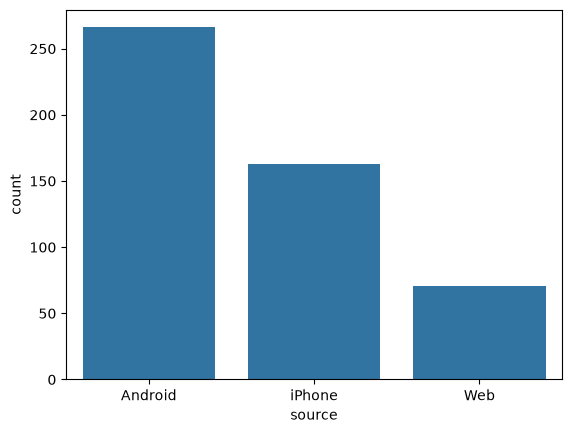

In [16]:
# Агрегируйте данные и постройте барчарт, где по оси x будет
# расположено название платформы (source),
# а по оси y – количество заказов (абсолютные значения)

#taxi_source_barplot = taxi.groupby('source').agg({'user_id': "count"}) \
#    .rename(columns={'user_id': "count"}) \
#    .sort_values('count')

#sns.barplot(
#    data=taxi_source,
#    x='source',
#    y='count'
#)

taxi_source = taxi['source'].value_counts().reset_index()
sns.barplot(
    data=taxi_source,
    x='source',
    y='count'
)


<Axes: xlabel='icon', ylabel='count'>

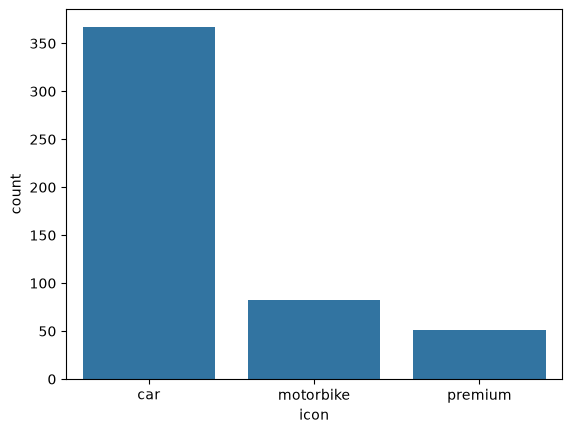

In [17]:
# какой тип поездки (icon) встречается чаще всего

#taxi_icon = taxi['icon'].value_counts().reset_index()

sns.countplot(
    data=taxi,
    x='icon',
)


<Axes: xlabel='source', ylabel='count'>

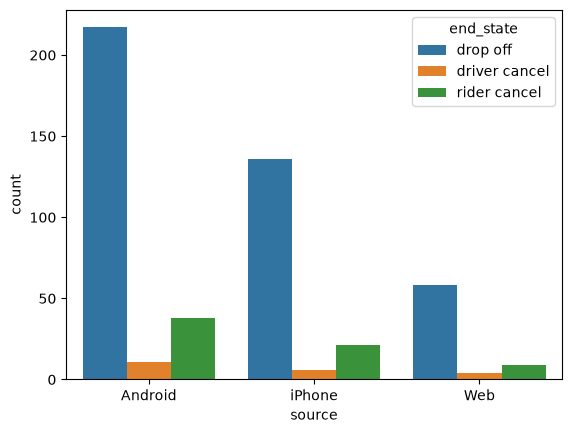

In [18]:
sns.countplot(x = taxi.source, hue = taxi.end_state)

In [24]:
# распределение оценки водителей

driver_score_counts = taxi.driver_score.value_counts(normalize=True) \
    .mul(100).round(2).reset_index() \
    .rename(columns={'proportion': 'percentage'}) \
    .sort_values('driver_score', ascending = False)

driver_score_counts

,driver_score,percentage
0,5,76.6
1,4,13.6
2,3,5.8
3,2,2.6
4,1,0.8
5,0,0.6


In [20]:
taxi.columns

Index(['journey_id', 'user_id', 'driver_id', 'taxi_id', 'icon', 'start_type',
       'start_at', 'start_lat', 'start_lon', 'end_at', 'end_lat', 'end_lon',
       'end_state', 'driver_start_lon', 'arrived_at', 'source', 'driver_score',
       'rider_score'],
      dtype='str')